In [1]:
"Melanoma Detection using Deep Learning: A Skin Cancer Classification Challenge"

'Melanoma Detection using Deep Learning: A Skin Cancer Classification Challenge'

Problem Statement:

Melanoma, the deadliest form of skin cancer, accounts for 75% of skin cancer-related deaths worldwide. Early detection is crucial for effective treatment and survival.Develop a Convolutional Neural Network (CNN) based model that can accurately classify skin lesions into melanoma or non-melanoma categories using the provided dataset. The goal is to create a reliable and efficient tool to assist dermatologists in early melanoma detection, reducing the need for invasive biopsies and improving patient outcomes. However, manual diagnosis by dermatologists can be time-consuming and prone to errors.

In [2]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import PIL
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
import warnings
warnings.filterwarnings("ignore")

Data Reading/Data Understanding

Defining the path for train and test images
Here is the link for the datasetng

C:\Users\ML\Downloads\archive.zip
C:\Users\ML\Downloads\archive.zip\Skin cancer ISIC The International Skin Imaging Collaboration
C:\Users\ML\Downloads\archive.zip\Skin cancer ISIC The International Skin Imaging Collaboration\Test
C:\Users\ML\Downloads\archive.zip\Skin cancer ISIC The International Skin Imaging Collaboration\Train


In [3]:

import os
os.listdir('/kaggle/input')


['skin-cancer9-classesisic']

This assignment uses a dataset of about 2357 images of skin cancer types. The dataset contains 9 sub-directories in each train and test subdirectories. The 9 sub-directories contains the images of 9 skin cancer types respectively.

In [4]:
import os

# List the files in the input directory
input_dir = '/kaggle/input/skin-cancer9-classesisic'
if os.path.exists(input_dir):
    print(f"Directory exists: {input_dir}")
    print("Files in the directory:")
    print(os.listdir(input_dir))
else:
    print(f"Directory does not exist: {input_dir}")


Directory exists: /kaggle/input/skin-cancer9-classesisic
Files in the directory:
['Skin cancer ISIC The International Skin Imaging Collaboration', 'skin cancer isic the international skin imaging collaboration']


Create a dataset
Define some parameters for the loader:

In [5]:
# Defining the path for train and test images
data_dir_train = pathlib.Path("../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/")
data_dir_test = pathlib.Path("../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test/")

In [6]:
batch_size = 32
img_height = 180
img_width = 180

In [7]:
# Loading the training data
# using seed=123 while creating dataset using tf.keras.preprocessing.image_dataset_from_directory
# resizing images to the size img_height*img_width, while writing the dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train,
                                                               seed=123,
                                                               validation_split=0.2,
                                                               image_size=(img_height,img_width),
                                                               batch_size=batch_size,
                                                               color_mode='rgb',
                                                               subset='training')

Found 2239 files belonging to 9 classes.
Using 1792 files for training.


In [8]:
# Loading the validation data
val_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train,
                                                             seed=123,
                                                             validation_split=0.2,
                                                             image_size=(img_height,img_width),
                                                             batch_size=batch_size,
                                                             color_mode='rgb',
                                                             subset='validation')

Found 2239 files belonging to 9 classes.
Using 447 files for validation.


In [9]:
# Loading the testing data
test_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_test,
                                                             seed=123,
                                                             image_size=(img_height,img_width),
                                                             batch_size=batch_size,
                                                             color_mode='rgb')

Found 118 files belonging to 9 classes.


In [10]:
# List out all the classes of skin cancer and store them in a list.
class_names = train_ds.class_names
print(class_names)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']



Number of images per class (Train and Test):
pigmented benign keratosis: Train=462, Test=16
melanoma: Train=438, Test=16
vascular lesion: Train=139, Test=3
actinic keratosis: Train=114, Test=16
squamous cell carcinoma: Train=181, Test=16
basal cell carcinoma: Train=376, Test=16
seborrheic keratosis: Train=77, Test=3
dermatofibroma: Train=95, Test=16
nevus: Train=357, Test=16


<Figure size 1200x600 with 0 Axes>

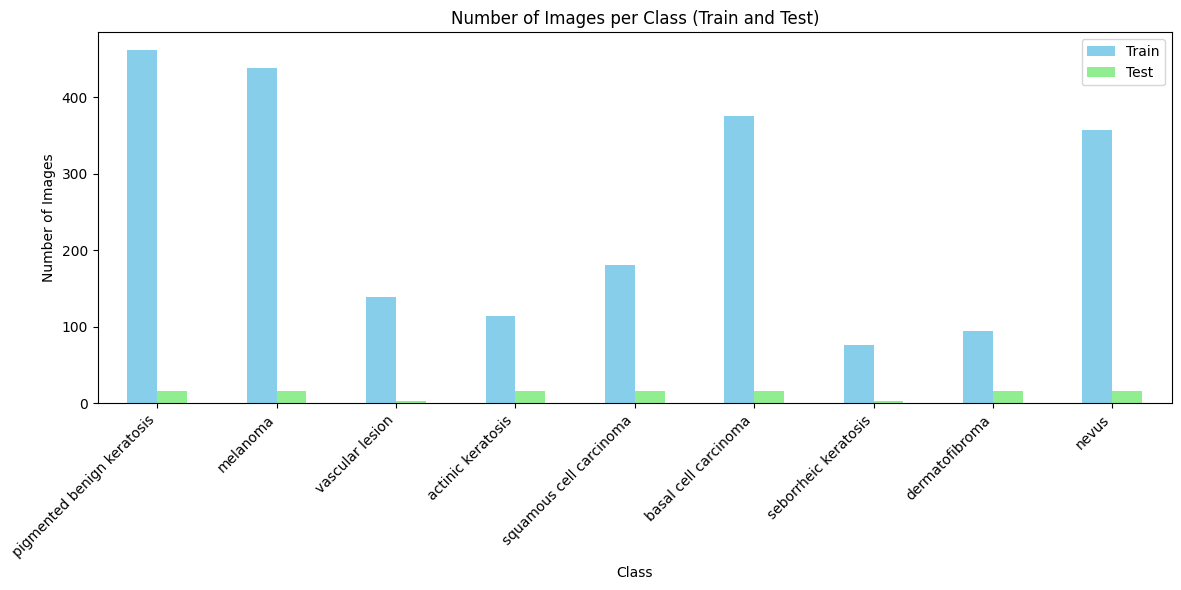


Dataset Summary:
                        Class  Image Count
0  pigmented benign keratosis          478
1                    melanoma          454
2             vascular lesion          142
3           actinic keratosis          130
4     squamous cell carcinoma          197
5        basal cell carcinoma          392
6        seborrheic keratosis           80
7              dermatofibroma          111
8                       nevus          373

Key Features and Challenges:
1. Dataset contains images categorized into the following classes:
['pigmented benign keratosis', 'melanoma', 'vascular lesion', 'actinic keratosis', 'squamous cell carcinoma', 'basal cell carcinoma', 'seborrheic keratosis', 'dermatofibroma', 'nevus']
2. Imbalance in class distribution may affect model performance.
3. Ensure proper preprocessing and augmentation to handle class imbalance.


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Path to the main dataset folder
dataset_path = '/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration'

# Assuming you have directories for Train and Test under the dataset path
train_dir = os.path.join(dataset_path, 'Train')  # Update if different
test_dir = os.path.join(dataset_path, 'Test')    # Update if different

# Check if the directories exist
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    print(f"Train or Test directory not found! Check the dataset structure.")

# Initialize train_classes and test_classes based on subdirectories
train_classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
test_classes = [d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]

# Initialize a dictionary to count images per class
class_counts = {}

# Function to get image files in a directory
def get_image_files(directory):
    return [f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Initialize image counts for each class
for class_name in train_classes + test_classes:
    class_counts[class_name] = {'Train': 0, 'Test': 0}

# Count images in Train and Test directories for each class
for class_name in train_classes:
    class_path = os.path.join(train_dir, class_name)
    class_counts[class_name]['Train'] = len(get_image_files(class_path))

for class_name in test_classes:
    class_path = os.path.join(test_dir, class_name)
    class_counts[class_name]['Test'] = len(get_image_files(class_path))

# Print the number of images per class
print("\nNumber of images per class (Train and Test):")
for class_name, counts in class_counts.items():
    print(f"{class_name}: Train={counts['Train']}, Test={counts['Test']}")

# Convert class_counts to a pandas DataFrame for easier exploration
data = pd.DataFrame.from_dict(class_counts, orient='index')

# Step 3: Visualize the distribution of images per class using matplotlib
plt.figure(figsize=(12, 6))
data.plot(kind='bar', stacked=False, color=['skyblue', 'lightgreen'], figsize=(12, 6))
plt.title('Number of Images per Class (Train and Test)')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha="right", fontsize=10)  # Adjust label rotation and horizontal alignment
plt.tight_layout()  # Ensure everything fits within the plot area
plt.show()

# Initialize image count dictionary for further exploration
image_counts = {}

# Explore the 'Train' and 'Test' directories
for subdir in ['Train', 'Test']:
    subdir_path = os.path.join(dataset_path, subdir)
    
    # Get all the class names (i.e., skin cancer types) within 'Train' or 'Test'
    class_names = [d for d in os.listdir(subdir_path) if os.path.isdir(os.path.join(subdir_path, d))]
    
    # Count images in each class for 'Train' and 'Test'
    for class_name in class_names:
        class_path = os.path.join(subdir_path, class_name)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        image_counts[class_name] = image_counts.get(class_name, 0) + len(image_files)

# Convert image_counts to a pandas DataFrame for easier exploration
data = pd.DataFrame(list(image_counts.items()), columns=['Class', 'Image Count'])

# Display dataset information
print("\nDataset Summary:")
print(data)

# Output: Explanation of key features and challenges
print("\nKey Features and Challenges:")
print("1. Dataset contains images categorized into the following classes:")
print(list(image_counts.keys()))
print("2. Imbalance in class distribution may affect model performance.")
print("3. Ensure proper preprocessing and augmentation to handle class imbalance.")


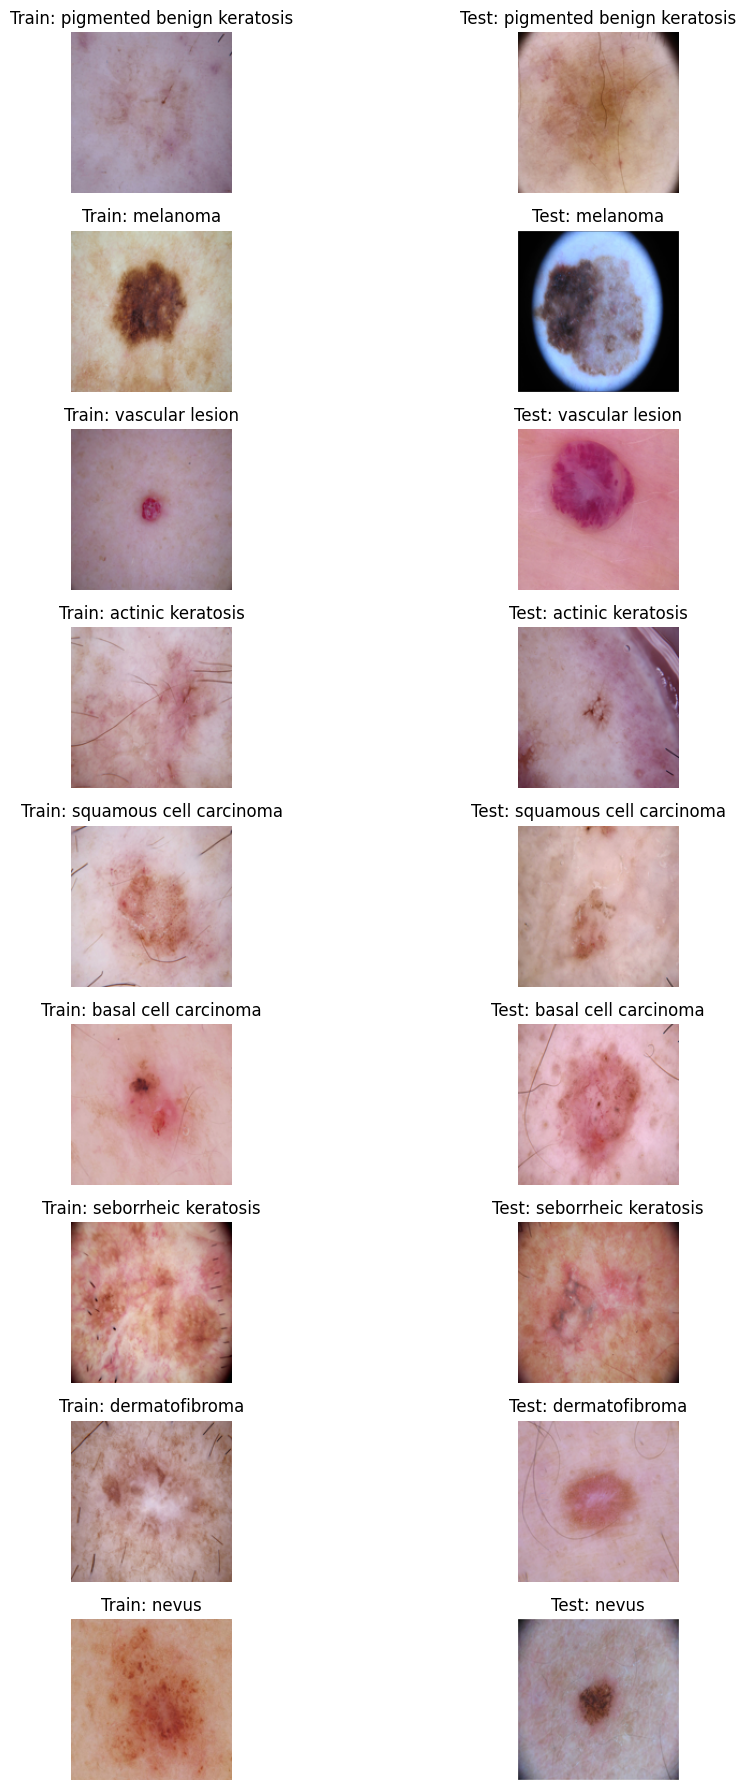

In [12]:
from PIL import Image
import os
import matplotlib.pyplot as plt

# Step 1: Explore one image per class from both 'Train' and 'Test' directories
# Initialize a subplot grid for displaying images (one row per class, two columns for Train and Test images)
fig, axes = plt.subplots(len(class_counts), 2, figsize=(12, 18))

# Loop through each class and display one image from both Train and Test
for i, class_name in enumerate(class_counts.keys()):
    # Get the first image from the Train class (if it exists)
    if class_counts[class_name]['Train'] > 0:
        train_class_path = os.path.join(train_dir, class_name)
        train_image_path = os.path.join(train_class_path, os.listdir(train_class_path)[0])  # Take the first image
        img_train = Image.open(train_image_path).resize((150, 150))  # Load image with resizing
        axes[i, 0].imshow(img_train)
        axes[i, 0].set_title(f"Train: {class_name}")
        axes[i, 0].axis('off')  # Hide axis

    # Get the first image from the Test class (if it exists)
    if class_counts[class_name]['Test'] > 0:
        test_class_path = os.path.join(test_dir, class_name)
        test_image_path = os.path.join(test_class_path, os.listdir(test_class_path)[0])  # Take the first image
        img_test = Image.open(test_image_path).resize((150, 150))  # Load image with resizing
        axes[i, 1].imshow(img_test)
        axes[i, 1].set_title(f"Test: {class_name}")
        axes[i, 1].axis('off')  # Hide axis

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


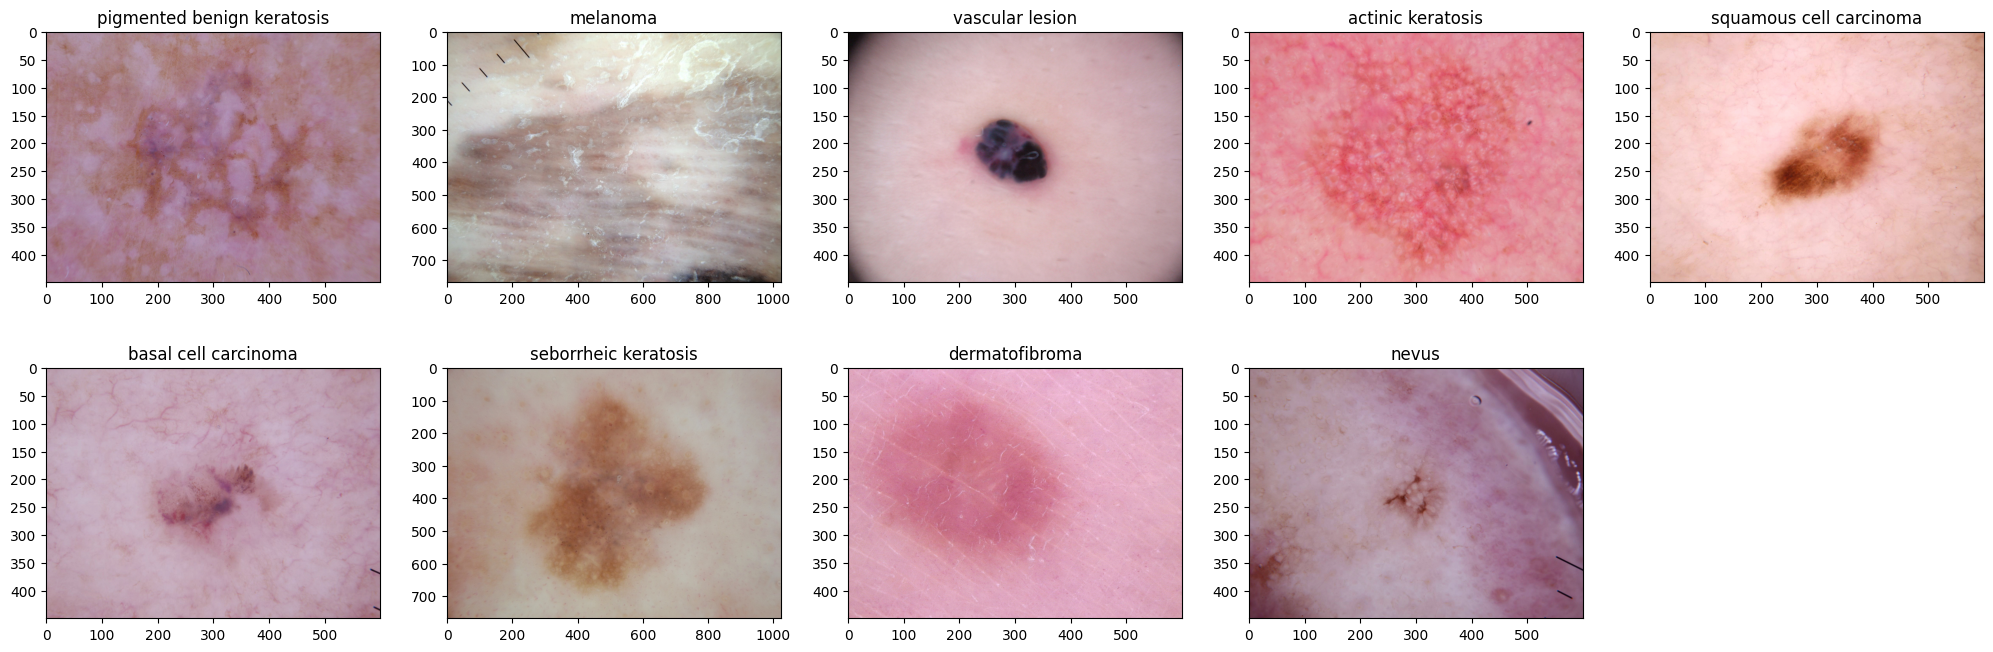

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(25,8))
for i in range(len(class_names)):
  plt.subplot(2,5,i+1)
  image= plt.imread(str(list(data_dir_train.glob(class_names[i]+'/*.jpg'))[1]))
  plt.title(class_names[i])
  plt.imshow(image)

In [14]:
# Configure the dataset for performance

AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# `Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch.\
# `Dataset.prefetch()` overlaps data preprocessing and model execution while training.

In [15]:
# Method to create plots of the loss and accuracy on the training and validation sets:
def plot_cnn_metrics(history,epochs):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

Step 3: Model Building and Training 
Build the CNN Model

Use convolutional layers for feature extraction and dense layers for classification.
Include dropout layers to prevent overfitting.
Compile and Train the Model

Use the Adam optimizer and sparse_categorical_crossentropy loss for multi-class classification.

Found 2239 files belonging to 9 classes.
Using 1792 files for training.
Found 2239 files belonging to 9 classes.
Using 447 files for validation.
Epoch 1/15


I0000 00:00:1733154068.090127      74 service.cc:145] XLA service 0x7df6ec026ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1733154068.090198      74 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1733154068.090202      74 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 5/56 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1654 - loss: 161.2782

I0000 00:00:1733154073.659016      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 176ms/step - accuracy: 0.2069 - loss: 50.0031 - val_accuracy: 0.1857 - val_loss: 2.1324
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.2320 - loss: 2.1997 - val_accuracy: 0.2483 - val_loss: 2.0658
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.2528 - loss: 2.0306 - val_accuracy: 0.2438 - val_loss: 2.0239
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.2271 - loss: 2.5012 - val_accuracy: 0.1969 - val_loss: 2.0365
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.2338 - loss: 2.3313 - val_accuracy: 0.2192 - val_loss: 2.4170
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.2217 - loss: 2.1722 - val_accuracy: 0.2103 - val_loss: 2.0257
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.2197 - loss: 2.0310 - val_accuracy: 0.2125 - val_loss: 2.0087
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.2153 - loss: 2.0080 - val_accuracy: 0.2058 - va

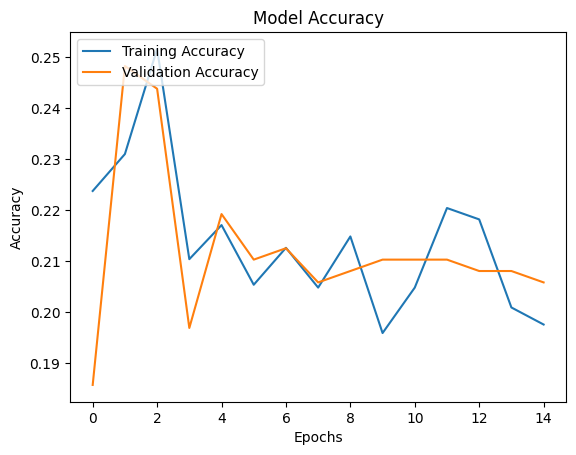

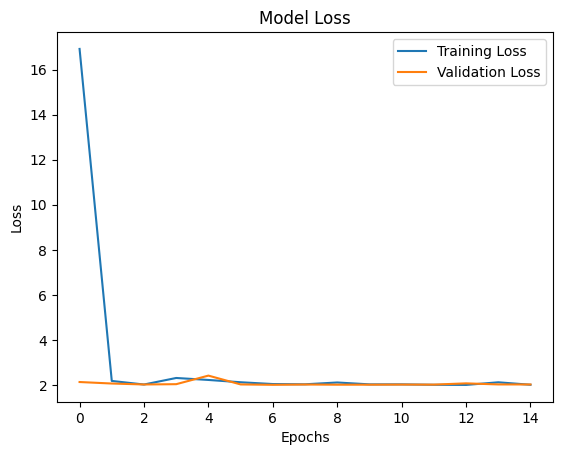

In [16]:
import pathlib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import matplotlib.pyplot as plt

# Defining the path for train and test images
data_dir_train = pathlib.Path("../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/")
data_dir_test = pathlib.Path("../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test/")

# Model Architecture
model = Sequential([
    Input(shape=(180, 180, 3)),  # Explicitly define input shape
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(9, activation='softmax')  # 9 classes
])

# Compile the Model
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Set batch size, image height, and image width
batch_size = 32
img_height = 180
img_width = 180

# Load training and validation datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    seed=123,
    validation_split=0.2,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb',
    subset='training'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    seed=123,
    validation_split=0.2,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb',
    subset='validation'
)

# Train the Model
history = model.fit(train_ds, validation_data=val_ds, epochs=15)

# Function to plot training metrics
def plot_cnn_metrics(history, epochs):
    # Plot training & validation accuracy values
    plt.plot(range(epochs), history.history['accuracy'], label='Training Accuracy')
    plt.plot(range(epochs), history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='upper left')
    plt.show()

    # Plot training & validation loss values
    plt.plot(range(epochs), history.history['loss'], label='Training Loss')
    plt.plot(range(epochs), history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.show()

# Plot the training metrics
plot_cnn_metrics(history, 15)


Step 4: Model Evaluation and Interpretation
Evaluate the Model

Use the test dataset to compute accuracy and loss.
Visualize performance metrics like confusion matrix and classification report.
Generate Visualizations

Confusion matrix to show class-wise predictions.
Grad-CAM++ for interpretability.

Found 1795 images belonging to 9 classes.
Found 444 images belonging to 9 classes.
Found 118 files belonging to 9 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.1206 - loss: 2.8176 - val_accuracy: 0.0428 - val_loss: 2.1973 - learning_rate: 1.0000e-04
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 499ms/step - accuracy: 0.0402 - loss: 2.1459 - val_accuracy: 0.0428 - val_loss: 2.1972 - learning_rate: 1.0000e-04
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 499ms/step - accuracy: 0.0746 - loss: 2.1350 - val_accuracy: 0.0608 - val_loss: 2.1972 - learning_rate: 1.0000e-04
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 497ms/step - accuracy: 0.0613 - loss: 2.2508 - val_accuracy: 0.0608 - val_loss: 2.1973 - learning_rate: 1.0000e-04
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 496ms/step - accuracy: 0.0710 - loss: 2.1526 - val_accuracy: 0.0428 - val_loss: 2.1972 - learning_rate: 1.0000e-04
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 5

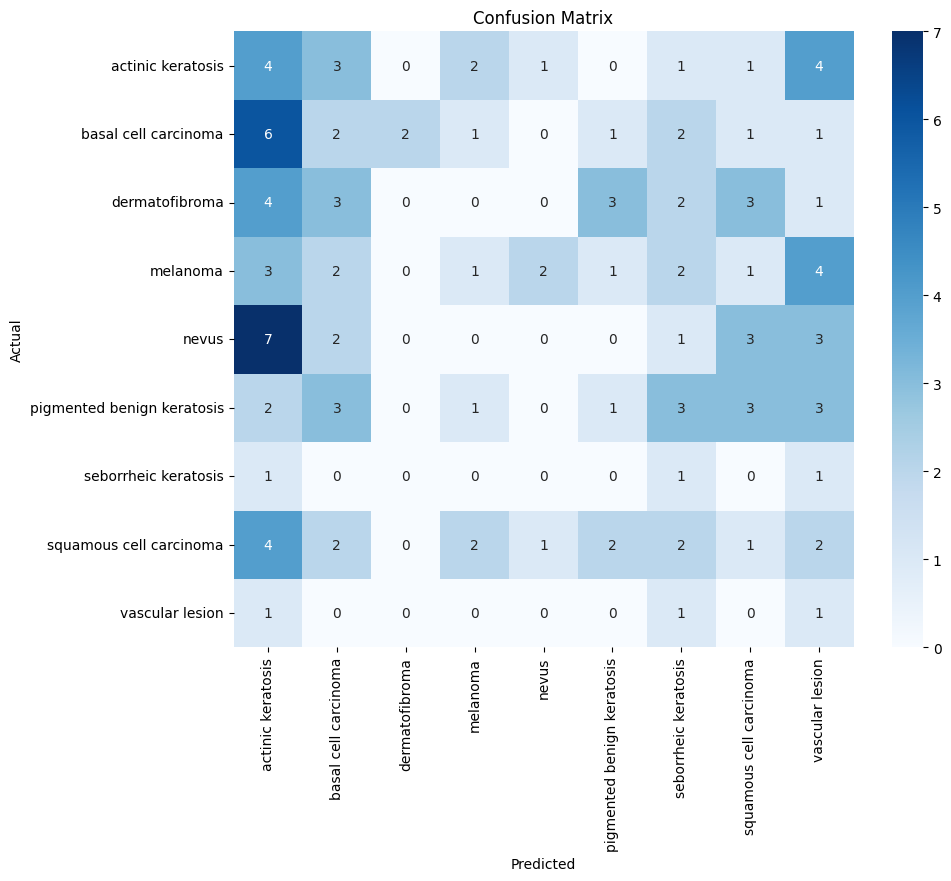


Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.12      0.25      0.17        16
      basal cell carcinoma       0.12      0.12      0.12        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.14      0.06      0.09        16
                     nevus       0.00      0.00      0.00        16
pigmented benign keratosis       0.12      0.06      0.08        16
      seborrheic keratosis       0.07      0.33      0.11         3
   squamous cell carcinoma       0.08      0.06      0.07        16
           vascular lesion       0.05      0.33      0.09         3

                  accuracy                           0.09       118
                 macro avg       0.08      0.14      0.08       118
              weighted avg       0.08      0.09      0.08       118



In [17]:
import pathlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# Defining the path for train, validation, and test images
data_dir_train = pathlib.Path("../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/")
data_dir_test = pathlib.Path("../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test/")

# Set batch size, image height, and image width
batch_size = 32
img_height = 180
img_width = 180

# Data augmentation and normalization
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values
    rotation_range=30,  # Increase rotation range
    width_shift_range=0.3,  # Increase width shift
    height_shift_range=0.3,  # Increase height shift
    horizontal_flip=True,  # Flip images
    validation_split=0.2  # Split dataset for validation
)

# Load training and validation datasets with augmentation
train_ds = datagen.flow_from_directory(
    data_dir_train,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse',
    subset='training'
)

val_ds = datagen.flow_from_directory(
    data_dir_train,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation'
)

# Load test dataset (no augmentation here)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_test,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb',
    label_mode='int'
)

# Implementing transfer learning with EfficientNetB0
base_model = EfficientNetB0(include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = True  # Unfreeze the base model

# Unfreeze the last 30 layers of EfficientNetB0
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Create the full model with the base model and a custom classifier
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(9, activation='softmax')  # 9 classes
])

# Compute the class weights using the labels in the training set
# The flow_from_directory automatically labels the data from class directories, so we use train_ds.classes
class_weights = compute_class_weight('balanced', classes=np.unique(train_ds.classes), y=train_ds.classes)

# Convert the computed class weights into a dictionary
class_weights = {i: class_weights[i] for i in range(len(class_weights))}

# Compile the model with a lower learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks for early stopping and learning rate reduction
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Train the model with class weights and callbacks
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler]
)

# After training, evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Generate predictions on the test dataset
y_pred = np.concatenate([np.argmax(model.predict(batch), axis=-1) for batch, _ in test_ds])
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])

# Class names from the dataset
class_names = test_ds.class_names

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Step 1: Data Preprocessing & Augmentation
Normalize the images by rescaling pixel values to the range [0, 1].

Increase data augmentation to create more diverse samples for training.

Modify your data generator to include more transformations:

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

 Step 2: Class Balancing
Compute Class Weights to handle class imbalance:


Apply class weights during training:

In [19]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights
)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 514ms/step - accuracy: 0.0663 - loss: 2.1820 - val_accuracy: 0.0608 - val_loss: 2.1972
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 494ms/step - accuracy: 0.0652 - loss: 2.1997 - val_accuracy: 0.0608 - val_loss: 2.1972
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 496ms/step - accuracy: 0.0586 - loss: 2.1867 - val_accuracy: 0.0428 - val_loss: 2.1972
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 492ms/step - accuracy: 0.0453 - loss: 2.1842 - val_accuracy: 0.0428 - val_loss: 2.1972
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 505ms/step - accuracy: 0.0453 - loss: 2.2090 - val_accuracy: 0.0428 - val_loss: 2.1973
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 503ms/step - accuracy: 0.0433 - loss: 2.2126 - val_accuracy: 0.0428 - val_loss: 2.1973
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 496ms/step - accuracy: 0.0429 - loss: 2.2038 - val_accuracy: 0.0428 - val_loss: 2.1973
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 501ms/step - accuracy: 0.0526 - loss: 2.1708 - val_accu

 Step 3: Model Architecture Improvement
Use EfficientNet or ResNet for better performance.

Example for EfficientNet:

In [20]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  # Freeze the layers initially

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(9, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Step 4: Hyperparameter Tuning
Use a Learning Rate Scheduler:

In [21]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

Add Early Stopping:

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

Step 5: Model Fine-Tuning
After initial training, unfreeze some layers of the base model (EfficientNet or ResNet).

In [23]:
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

Step 6: Evaluation and Visualization
Use a confusion matrix to visualize how well your model is performing across different classes.

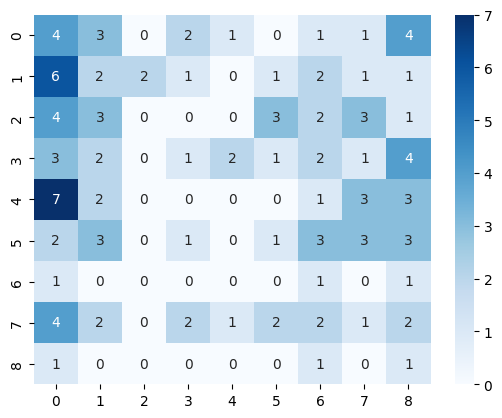

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

Step 5: Visual Interpretations (Grad-CAM++) 
Grad-CAM++ for Feature Localization
Highlight the regions in images that influenced the model's predictions.

In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ ?                      │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │   0 (unbuilt) │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 3,840,348 (14.65 MB)

 Non-trainable params: 209,223 (817.28 KB)